# DS4DS Homework Exercise Sheet 11

**General Instructions:**

- Collaborations between students during problem-solving phase on a discussion basis is OK
- However: individual code programming and submissions per student are required
- Code sharing is strictly prohibited
- We will run checks for shared code, general plagiarism and AI-generated solutions
- Any fraud attempt will lead to an auto fail of the entire course
- Do not use any additional packages except for those provided in the task templates
- Please use Julia Version 1.10.x to ensure compatibility
- Please only write between the `#--- YOUR CODE STARTS HERE ---#` and `#--- YOUR CODE ENDS HERE ---#` comments
- Please do not delete, add any cells or overwrite cells other than the solution cells (**Tip:** If you use a jupyerhub IDE, you should not be able to add or delete cells and write in the non-solution cells by default)

In [2]:
using Printf
using DelimitedFiles, Plots, GZip, StatsBase, LaTeXStrings, Serialization
using OrdinaryDiffEq, Lux, Random, ComponentArrays
using DataInterpolations, SciMLSensitivity, Optimization, OptimizationOptimJL, LineSearches, Zygote, OptimizationFlux, Flux

In [17]:
using Pkg

In [18]:
Pkg.status()

Status `/opt/julia/environments/v1.10/Project.toml`
⌃ [6e4b80f9] BenchmarkTools v1.5.0
  [1e616198] COSMO v0.8.9
⌃ [13f3f980] CairoMakie v0.12.9
⌅ [5ae59095] Colors v0.12.11
⌃ [b0b7db55] ComponentArrays v0.15.16
⌃ [82cc6244] DataInterpolations v6.4.0
  [8bb1440f] DelimitedFiles v1.9.1
⌃ [6a86dc24] FiniteDiff v2.24.0
⌅ [587475ba] Flux v0.14.19
⌃ [f6369f11] ForwardDiff v0.10.36
  [92fee26a] GZip v0.6.2
⌃ [3955a311] GridLayoutBase v0.11.0
  [f67ccb44] HDF5 v0.17.2
⌃ [7073ff75] IJulia v1.25.0
⌃ [4076af6c] JuMP v1.23.1
⌃ [b964fa9f] LaTeXStrings v1.3.1
  [d3d80556] LineSearches v7.3.0
⌃ [b2108857] Lux v1.0.5
  [23992714] MAT v0.10.7
⌃ [429524aa] Optim v1.9.4
⌅ [7f7a1694] Optimization v3.27.0
  [253f991c] OptimizationFlux v0.2.1
⌃ [36348300] OptimizationOptimJL v0.3.2
⌃ [1dea7af3] OrdinaryDiffEq v6.89.0
⌃ [91a5bcdd] Plots v1.40.1
⌃ [c3e4b0f8] Pluto v0.19.46
⌃ [1ed8b502] SciMLSensitivity v7.65.0
⌃ [2913bbd2] StatsBase v0.34.3
⌅ [e88e6eb3] Zygote v0.6.70
  [37e2e46d] LinearAlgebra
  [9a3f8284] 

## Task 1: NODE model for a SISO heating system - (6 points)

In this task, we consider a simple single-input-single-output (SISO) heating system. The input of the system $u(t)$ is the voltage that drives a  halogen lamp which is suspended several inches above a thin steel plate. The output of the system $y(t)$ is a thermocouple measurement taken from the back of the plate ([source](https://ftp.esat.kuleuven.be/pub/SISTA/data/thermic/) and [description](https://ftp.esat.kuleuven.be/pub/SISTA/data/thermic/heating_system.txt) of the dataset).

Our goal within this task will be to identify the dynamics of the underlying process. We make the assumption that the temperature measurment holds sufficient information to characterize the process, i.e., that $\hat{x}(t) = \hat{y}(t)$ applies. We will build a model

$$
\begin{align}
    \frac{\mathrm{d}}{\mathrm{d}t} \hat{x}(t) &= \mathcal{M}_{\mathbf{w}} (\hat{x}(t), u(t)) \\
    \hat{y}(t) & = \hat{x} (t)
\end{align}
$$

that estimates the change of temperature. To this end, we will make use of neural ordinary differential equations (NODEs).

The basic idea of NODEs is to use an artifical neural network (ANN) to model the state transition equation $\frac{\mathrm{d}}{\mathrm{d}t} \hat{x}(t) = \mathcal{M}_{\mathbf{w}} (\hat{x}(t), u(t))$ that is parameterized by $\mathbf{w}$. The resulting ODE is then solved by standard ODE solvers to yield an estimate for the state trajectory. This estimated state trajectory is then compared to the target trajectory to optimize the parameters in the ANN and improve the approximation.

#### Function for dataset loading:

In [19]:
function loaddata_heating(; normalize=true)
    fh = GZip.open("heating_system.dat.gz")
    data = readdlm(fh)

    data_freq = 4
    
    data = data[1:data_freq:end, :]
    
    t = data[:, 1] / 16  # time in seconds
    u = data[:, 2]  # input: voltage driving the lamp in volt
    y = data[:, 3]  # output: temperature measurement in °C

    
    dt = 2 * data_freq / 16  # time between samples in seconds (thermic process -> high inertia)
    
    # convert to Float32 for performance
    t = Float32.(t)
    u = Float32.(u) 
    y = Float32.(y)
    
    if normalize  # optional standardization of data
        dty = fit(ZScoreTransform, y)
        dtu = fit(ZScoreTransform, u)
    
        y = StatsBase.transform(dty, y)
        u = StatsBase.transform(dtu, u);
    end
    
    tspan = (t[1], t[end])
    
    return u, y, dt, tspan, t
end

loaddata_heating (generic function with 1 method)

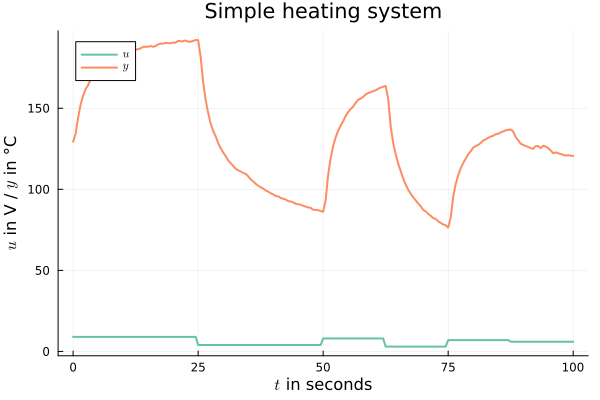

In [20]:
u, y, dt, tspan, tsteps = loaddata_heating(normalize = false)
p = plot(tsteps, u, label=L"u", title="Simple heating system", xlabel=L"$t$ in seconds", ylabel=L"$u$ in V / $y$ in °C",
     legend=:topleft, lw=2, palette = :Set2_5)
plot!(p, tsteps, y, label=L"y", lw =2)

#### **a)** - (0.5 point)
Split your dataset into a training and evaluation dataset. The training dataset will be used to tune the parameters of your model and the evaluation data will be used to evaluate the generalization performance of your model.
Use $u(t >= 37.5s)$ and $y(t >= 37.5s)$ for the training and $u(t < 37.5s)$ and $y(t < 37.5s)$ for the evaluation datasets. Additionally, provide the corresponding timesteps for the training and eval datasets, i.e., provide
```tsteps_training``` which contains all timesteps from the dataset with $t >= 37.5s$ and ```tsteps_eval``` which contains all timesteps with $t < 37.5s$.

Implement the function below to split the dataset.

In [21]:
u, y, dt, tspan, tsteps = loaddata_heating();

function split_dataset(u, y, tsteps)
    """
    Creates a training and evaluation split
    
    Args:
        u: System input data
        y: System output data
        tsteps: time steps of the data trajectories

    Returns:
        u_training: u(t >= 37.5s)
        y_training: y(t >= 37.5s)
        u_eval: u(t < 37.5s)
        y_eval: y(t < 37.5s)
        tsteps_training: time steps for the training data
        tsteps_eval: time steps for the eval data
    """
    ### BEGIN SOLUTION

    belonging_to_training = tsteps .>= 37.5
    belonging_to_eval = tsteps .< 37.5
    
    u_training = u[belonging_to_training]
    y_training = y[belonging_to_training]
    tsteps_training = tsteps[belonging_to_training]
    
    u_eval = u[belonging_to_eval]
    y_eval = y[belonging_to_eval]
    tsteps_eval = tsteps[belonging_to_eval]
    
    ### END SOLUTION

    return u_training, y_training, u_eval, y_eval, tsteps_training, tsteps_eval
end
    
u_training, y_training, u_eval, y_eval, tsteps_training, tsteps_eval = split_dataset(u, y, tsteps);

In [22]:
@assert isa(split_dataset, Function)
@assert vcat(u_eval, u_training) == u  "Full dataset needs to be the concatenation of training and eval sets"
@assert vcat(y_eval, y_training) == y  "Full dataset needs to be the concatenation of training and eval sets"

### BEGIN HIDDEN TESTS

belonging_to_training = tsteps .>= 37.5
belonging_to_eval = tsteps .< 37.5
u_training_test = u[belonging_to_training]
y_training_test = y[belonging_to_training]
u_eval_test = u[belonging_to_eval]
y_eval_test = y[belonging_to_eval]

@assert u_eval == u_eval_test
@assert u_training == u_training_test
@assert y_eval == y_eval_test
@assert y_training == y_training_test

### END HIDDEN TESTS

In [23]:
# Please leave this cell as it is
### BEGIN HIDDEN TESTS

# Fix for consecutive tests
u, y, dt, tspan, tsteps = loaddata_heating()
d
belonging_to_training = tsteps .>= 37.5
belonging_to_eval = tsteps .< 37.5

u_training = u[belonging_to_training]
y_training = y[belonging_to_training]
tsteps_training = tsteps[belonging_to_training]

u_eval = u[belonging_to_eval]
y_eval = y[belonging_to_eval]
tsteps_eval = tsteps[belonging_to_eval]

0;
### END HIDDEN TESTS

#### **b)** - (1 point)
Implement a function for the creation of a fully-connected feed-forward neural network in dependence of the layer sizes and the activation functions. Use ```Lux.jl``` to implement it in the function template given below.

In [24]:
function create_ann(layer_sizes, hidden_layer_activation_function, output_activation)
    """
    Creates a neural network with the given parameters

    Args:
        layer_sizes: List of layer sizes (e.g. [5, 32, 32, 2])
        hidden_layer_activation_function: Activation function for all hidden layers (nomenclature of Lux.jl)
        output_activation: Activation function of the output layer (nomenclature of Lux.jl)

    Returns:
        ann: Resulting fully-connected neural network
    """
    ### BEGIN SOLUTION

    chain_elements = [Lux.Dense(m, n, hidden_layer_activation_function) for (m, n) in zip(layer_sizes[1:end-2], layer_sizes[2:end-1])]
    chain_elements = vcat(chain_elements, Lux.Dense(layer_sizes[end-1], layer_sizes[end], output_activation))
    ann = Lux.Chain(chain_elements)

    ### END SOLUTION

    return ann
end

# the sizes you choose here have no influence on the grading of this subtask
layer_sizes = nothing
hidden_layer_activation_function = nothing
output_activation = nothing

### BEGIN SOLUTION
layer_sizes = [2, 40, 40, 1]
hidden_layer_activation_function = tanh
output_activation = x -> x
### END SOLUTION

#9 (generic function with 1 method)

In [25]:
ann = create_ann(layer_sizes, hidden_layer_activation_function, output_activation)
@assert isa(ann, Lux.Chain)

### BEGIN HIDDEN TESTS
test_ann = create_ann([2, 40, 40, 1], tanh, x -> x)

@assert length(test_ann) == 3

@assert test_ann[1].in_dims == 2
@assert test_ann[1].out_dims == 40

@assert test_ann[2].in_dims == 40
@assert test_ann[2].out_dims == 40

@assert test_ann[3].in_dims == 40
@assert test_ann[3].out_dims == 1

@assert isa(test_ann.layers.layer_1.activation, Function)
@assert isa(test_ann.layers.layer_2.activation, Function)
@assert isa(test_ann.layers.layer_3.activation, Function)

### END HIDDEN TESTS

#### **c)** - (1 point)

In this subtask, we want to define the NODE of the form

$$
\begin{align}
    \frac{\mathrm{d}}{\mathrm{d}t} \hat{x}(t) &= \mathcal{M}_{\mathbf{w}} (\hat{x}(t), u(t)).
\end{align}
$$

To this end, we need to define the ODE in the function ```dxdt(x, w, t)``` and initialize the ```training_problem```.
Use ```create_ann``` from subtask **b)** to create a model for the ODE. If you were unable to properly implement it in **b)**, you are also allowed to create a model manually. However, you are restricted to fully-connected feed-forward neural networks. Use the variable ```w``` for the model parameters $\mathbf{w}$.

The layer sizes, activation functions and initialization are set here to help you with the following subtask.
If you want to design a different network, you are free to do so. Note, however that you might face a more complex optimization in that case.

In [26]:
# theoretically you would need to interpolate separately for training and evaluation, but we will look past this here
# as the time is already dividing between the two
interp_input = AkimaInterpolation(u, tsteps);

ann = create_ann([2, 8, 4, 1], tanh, x -> x)

# initialize parameter and state variables

# using this seed for initialization the intial state of the model is quite good for the task,
# otherwise the optimization is too complex for the given ressources..
seed = 2 

w, st = Lux.setup(MersenneTwister(seed), ann);
w = ComponentArray(w);

dxdt(x, w, t) = nothing  # ODE function
training_prob = nothing  # ODE training problem

### BEGIN SOLUTION
dxdt(x, w, t) = ann([x; interp_input(t)], w, st)[1]  # define ODE
training_prob = ODEProblem(dxdt, [y_training[1]], (tsteps_training[1], tsteps_training[end]), w)  # create training problem
### END SOLUTION

ODEProblem with uType Vector{Float32} and tType Float32. In-place: false
timespan: (37.5f0, 100.0f0)
u0: 1-element Vector{Float32}:
 -0.9407533

In [27]:
@assert isa(dxdt, Function)
@assert isa(training_prob, ODEProblem)

### BEGIN HIDDEN TESTS

# simple sanity check that for all parameters = 0, nothing happens
w_test = zero(w)
test_start = [0.8]
tsteps_test = LinRange(20, 30, 50)

test_problem = ODEProblem(dxdt, test_start, (tsteps_test[1], tsteps_test[end]), w_test)
@assert test_start == solve(test_problem, Vern7(); u0=test_start, p=w_test, saveat=tsteps_test, dt, adaptive=false).u[end]

### END HIDDEN TESTS

#### **d)** - (0.5 points)
Next, we want to implement the forward pass of the NODE.

Implement the function below that takes the parameters of the model $\mathbf{w}$, an ODE problem, the initial state $x_0$ and the timesteps and returns the state trajectory $\hat{\mathbf{x}}_n$.
Use the Tsit5 ODE solver, but non-adaptive.

In [28]:
function predict_NODE(w, problem, x0, tsteps, dt)
    """
    NODE forward pass

    Args:
        w: Parameters of the model as a ComponentArray
        problem: ODE problem
        x0: Initial state of the trajectory
        tsteps: Time steps of the trajectory
        dt: The time between two samples in the trajectory

    Returns:
        Resulting state trajectory
    
    """
    ### BEGIN SOLUTION
    return Array(solve(problem, Tsit5(); u0=x0, p=w, saveat=tsteps, dt, adaptive=false))
    ### END SOLUTION
end;

In [1]:
@assert isa(predict_NODE, Function)

### BEGIN HIDDEN TESTS

dummy_ode(x, w, t) = w * x
test_x0 = 2
test_w = 0.5

test_dt = 0.1
test_tsteps = LinRange(0, 1, 10)

trajectory = predict_NODE(
    test_w,
    ODEProblem(dummy_ode, test_x0, (test_tsteps[1], test_tsteps[end]), test_w),
    test_x0,
    test_tsteps,
    test_dt
)

println("Given trajectory: ", trajectory)

expected_trajectory = [2.0, 2.114255489520473, 2.2350381374837274, 2.362720825731292, 2.497697738003365, 2.640385576868242, 2.7912248501721817, 2.950681230981243, 3.119246995213576, 3.297442541400258]
@assert isapprox(expected_trajectory, trajectory, rtol=0, atol=1e-6)

### END HIDDEN TESTS

LoadError: UndefVarError: `predict_NODE` not defined

#### **e)** 
Implement the MSE loss function to compare model predictions and true trajectory. Optimize the parameters $\mathbf{w}$ of your model given in subtask c) using the given optimizer.
Design an adequate optimization problem for the given template.

**Note:** The code itself will generally not be evaluated in this subtask, but only the performance on the evaluation set. We will inspect your optimization routine more closely if it looks suspicious.

In [30]:
#your final model parameters
result = nothing

optimizer = OptimizationFlux.Adam(1e-3)
maxiters = 2_000

function callback(state, l)
	state.iter % 100 == 0 && @printf "Iteration: %5d, Training loss: %.6e\n" state.iter l

    # extend the callback if you like, the parameters can be accessed as state.u
    ### BEGIN SOLUTION
    
    ### END SOLUTION
	return false
end

### BEGIN SOLUTION

function loss_NODE(w)
    
    pred = predict_NODE(w, training_prob, [y_training[1]], tsteps_training, dt)   
    loss = sum(abs2, y_training .- pred[1,:])

    return loss
end


adtype = Optimization.AutoZygote()
optf = Optimization.OptimizationFunction((w, p) -> loss_NODE(w), adtype)
optprob = Optimization.OptimizationProblem(optf, w);

### END SOLUTION

result = Optimization.solve(
    optprob,
    optimizer,
    maxiters=maxiters,
    callback=callback
)

# save your model parameters
if @isdefined result
    #Save your model as file
    @assert isa(result, SciMLBase.OptimizationSolution)
    serialize("model_task_1",result)
end

Iteration:   100, Training loss: 6.431092e+00
Iteration:   200, Training loss: 3.446160e+00
Iteration:   300, Training loss: 1.512623e+00
Iteration:   400, Training loss: 9.366498e-01
Iteration:   500, Training loss: 8.025057e-01
Iteration:   600, Training loss: 7.396802e-01
Iteration:   700, Training loss: 6.931447e-01
Iteration:   800, Training loss: 6.550248e-01
Iteration:   900, Training loss: 6.225671e-01
Iteration:  1000, Training loss: 5.939710e-01
Iteration:  1100, Training loss: 5.677724e-01
Iteration:  1200, Training loss: 5.425785e-01
Iteration:  1300, Training loss: 5.173312e-01
Iteration:  1400, Training loss: 4.922356e-01
Iteration:  1500, Training loss: 4.681039e-01
Iteration:  1600, Training loss: 4.451928e-01
Iteration:  1700, Training loss: 4.233992e-01
Iteration:  1800, Training loss: 4.025975e-01
Iteration:  1900, Training loss: 3.827611e-01
Iteration:  2000, Training loss: 3.639935e-01
Iteration:  2000, Training loss: 3.639935e-01


After you have trained your model, save the parameters using the code above into the file `model_task_1`. 

**Then comment out your optimization code in the cell above and remove your saving code so that both do not run in the autograding!**

In [31]:
# load your model parameters

student_model = deserialize("model_task_1")
@assert isa(student_model, SciMLBase.OptimizationSolution)

student_w = student_model.u  # extract parameters

ComponentVector{Float32}(layer_1 = (weight = Float32[-0.1852646 1.0052416; 0.82081234 1.4979628; … ; 1.9562061 0.76397145; 0.2641696 -1.520132], bias = Float32[0.46346632, -0.06435773, -0.0395407, 0.06272176, -0.6955067, -0.49638054, 0.021726884, -0.29611516]), layer_2 = (weight = Float32[0.37785253 -1.0755603 … 1.7894908 0.953412; -0.7449028 -0.92587656 … -1.0111138 -0.5648185; 0.89616704 0.31239536 … -0.50430757 -0.41149563; -0.7355229 -0.33590272 … 0.36911547 0.70918465], bias = Float32[0.7275671, 0.046328794, 0.23403601, -0.057273492]), layer_3 = (weight = Float32[-0.108506404 -0.7282037 0.5061245 0.20062411], bias = Float32[-0.07617065]))

#### **f)** - (3 points)
Evaluate the performance of your model on the evaluation dataset. To do so, define the evaluation problem.

To gain the points for this subtask, you have to produce a model that reaches an MSE between the prediction and the eval trajectory lower than the threshold given below.
The previously given architecture and optimization parameters should help you reach this prediction accuracy.

In [32]:
x0 = nothing
evaluation_problem = nothing

### BEGIN SOLUTION
x0 = y_eval[1]
evaluation_problem = ODEProblem(dxdt, x0, (tsteps_eval[1], tsteps_eval[end]), student_w)
### END SOLUTION

ODEProblem with uType Float32 and tType Float32. In-place: false
timespan: (0.0f0, 37.0f0)
u0: -0.1329399f0

In [33]:
@assert isa(x0,Number)
@assert isa(evaluation_problem, ODEProblem)

prediction_eval = predict_NODE(student_w, evaluation_problem, [x0] , tsteps_eval, dt)[1,:]

@assert length(prediction_eval) == length(tsteps_eval)

prediction_error_eval = Flux.mse(prediction_eval, y_eval)
println("Given prediction error: ", prediction_error_eval)

@assert prediction_error_eval <= 0.3

Given prediction error: 0.14682999


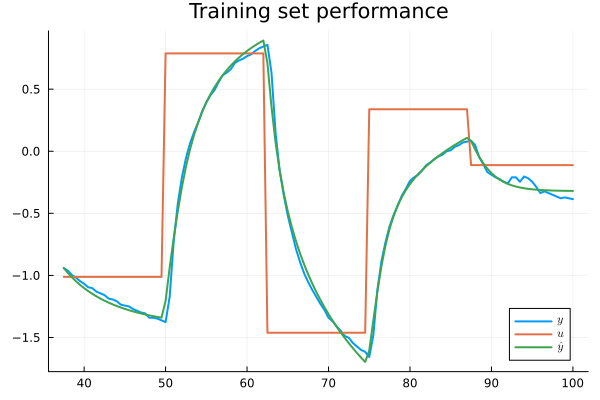

In [34]:
prediction_training = predict_NODE(student_w, training_prob, [y_training[1]] , tsteps_training, dt)[1,:]

p = plot(tsteps_training, y_training, label=L"y", lw =2, title="Training set performance")
plot!(p, tsteps_training, u_training, label=L"u", lw =2)
plot!(p, tsteps_training, prediction_training, label=L"\hat{y}", lw =2)

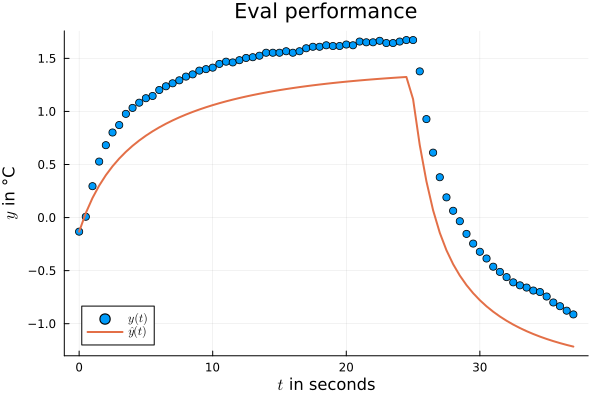

In [35]:
eval_plot = scatter(tsteps_eval, y_eval, label=L"$y(t)$", title="Eval performance", xlabel=L"$t$ in seconds", ylabel=L"$y$ in °C", legend=:bottomleft, lw=2)
plot!(eval_plot, tsteps_eval, prediction_eval, label=L"$\hat{y}(t)$", lw =2)

## Task 2: NODE model for Lake Erie (MIMO) - (4 points)

In this task, we once again model an underlying process using NODEs. However, the system at hand now takes multiple inputs $\mathbf{u}(t)$ and yields multiple outputs $\mathbf{y}(t)$. This means we need to model a multiple-input-multiple-output (MIMO) system.

This results in the dynamics equations 

$$
\begin{align}
    \frac{\mathrm{d}}{\mathrm{d}t} \hat{\mathbf{x}}(t) &= \mathcal{M}_{\mathbf{w}} (\hat{\mathbf{x}}(t), \mathbf{u}(t)) \\
    \hat{\mathbf{y}}(t) & = \hat{\mathbf{x}} (t).
\end{align}
$$

The data ([source](https://ftp.esat.kuleuven.be/pub/SISTA/data/environmental/) and [description](https://ftp.esat.kuleuven.be/pub/SISTA/data/environmental/erie.txt) of the dataset) is the result of a simulation of the western basin of Lake Erie. The inputs $\mathbf{u}(t)$ are the water temperature, water conductivity, water alkalinity, the NO3 content and the total hardness of the water. The outputs $\mathbf{y}(t)$ are the amount of dissolved oxigen and the algae content. We are interested in the dynamic relationship between inputs and outputs described by the model above.

#### a) - (1 point)

Below you are shown the raw output data:

![lake_erie-not_normalized](./LakeErie-NotNormalized.svg)

You can see that the two outputs are scaled very differently. As a result, we need to normalize them separately.

Implement the function below to normalize each output separately. Use `StatsBase.fit(ZScoreTransform, ...)` and `StatsBase.transform(...)` for the normalization.

In [36]:
function normalize_columnwise(data)

    ### BEGIN SOLUTION

    normalized_data = zeros(size(data))
    for i in 1:size(data)[2]
        column = Float32.(data[:, i])
        
        dt_column = StatsBase.fit(ZScoreTransform, column)
        normalized_data[:, i] = StatsBase.transform(dt_column, column)
    end
    
    ### END SOLUTION
    
    return normalized_data
end

function loaddata_erie(; normalize= true)
    fh = GZip.open("erie.dat.gz")
    data = readdlm(fh)
    
    t = data[:, 1]  # time in months
    u = data[:, 2:6]
    y = data[:, 22:23]
    
    dt = 1  # time between samples in months
    
    # convert to Float32 for performance
    t = Float32.(t)
    u = Float32.(u) 
    y = Float32.(y)
    
    if normalize  # optional standardization of data
        y = normalize_columnwise(y)
        u = normalize_columnwise(u)
    end
    
    tspan = (t[1], t[end])
    
    return u, y, dt, tspan, t
end

loaddata_erie (generic function with 1 method)

Code for plot below when the data is normalized properly:
```
p = plot(tsteps, y, label=L"y", title="Lake Erie", xlabel=L"$t$ in months", ylabel=L"y", legend=:topleft, background_color="#000000",lw=2, palette = :Set2_5)
```

![lake_erie](./LakeErie.svg)

In [37]:
isa(normalize_columnwise, Function)

### BEGIN HIDDEN TESTS

test_data = reduce(hcat, [LinRange(-1, 1, 10), LinRange(-5, 0, 10), LinRange(12, 4596, 10)])

normalized_data = normalize_columnwise(test_data)

expected_column = [-1.4863, -1.15601, -0.825723, -0.495434, -0.165145, 0.165145, 0.495434, 0.825723, 1.15601, 1.4863]

for idx in 1:size(normalized_data, 2)
    norm_column = normalized_data[:, idx]
    println("Given column: ", norm_column)
    @assert isapprox(norm_column, expected_column, rtol=0, atol=1e-4) 
end

### END HIDDEN TESTS

Given column: [-1.486301064491272, -1.156011939048767, -0.8257228136062622, -0.4954336881637573, -0.16514453291893005, 0.16514457762241364, 0.4954336881637573, 0.8257228136062622, 1.156011939048767, 1.486301064491272]
Given column: [-1.486301064491272, -1.1560120582580566, -0.8257227540016174, -0.49543362855911255, -0.16514448821544647, 0.16514448821544647, 0.4954336881637573, 0.8257227540016174, 1.156011939048767, 1.486301064491272]
Given column: [-1.4863009452819824, -1.156011939048767, -0.8257227540016174, -0.49543365836143494, -0.16514460742473602, 0.16514460742473602, 0.49543365836143494, 0.8257226943969727, 1.156011939048767, 1.4863009452819824]


In [38]:
# please leave this cell as it is

### BEGIN HIDDEN TESTS
# Fix for consecutive tests

function normalize_columnwise(data)

    normalized_data = zeros(size(data))
    for i in 1:size(data)[2]
        column = Float32.(data[:, i])
        
        dt_column = StatsBase.fit(ZScoreTransform, column)
        normalized_data[:, i] = StatsBase.transform(dt_column, column)
    end
    
    return normalized_data
end

0;
### END HIDDEN TESTS

#### Preparations:

In [39]:
u, y, dt, tspan, tsteps = loaddata_erie(normalize=true)
print(size(u))

# interpolate inputs for all channels separately
interp_input = [AkimaInterpolation(u[:, i], tsteps) for i in 1:size(u, 2)]
function interpolate_input(t)
    return [f(t_) for (f, t_) in zip(interp_input, ones(size(interp_input, 1))* t)]
end

(57, 5)

interpolate_input (generic function with 1 method)

In [40]:
belonging_to_training = tsteps .<= 40
belonging_to_eval = tsteps .> 40

u_training = u[belonging_to_training, :]
y_training = y[belonging_to_training, :]
tsteps_training = tsteps[belonging_to_training, :]

u_eval = u[belonging_to_eval, :]
y_eval = y[belonging_to_eval, :]
tsteps_eval = tsteps[belonging_to_eval, :];

tsteps_training = vec(tsteps_training)
tsteps_eval = vec(tsteps_eval);

#### **b)**

Build and train a NODE model using the training dataset. Design a feed-forward fully-connected neural network as the model.

Iteration:   100, training loss: 5.750335e+02
Iteration:   200, training loss: 4.545820e+02
Iteration:   300, training loss: 3.340846e+02
Iteration:   400, training loss: 2.253360e+02
Iteration:   500, training loss: 1.487815e+02
Given prediction error: 2.4748261573720205


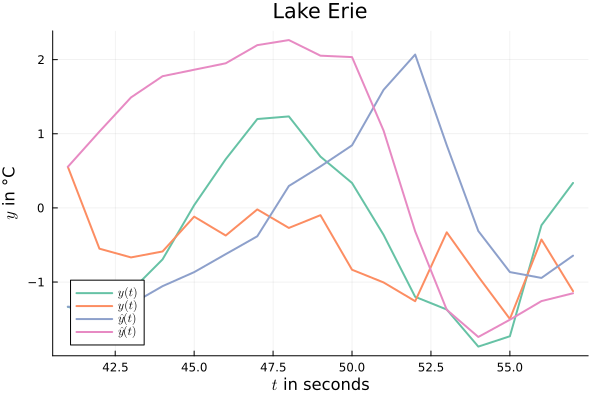

Iteration:   600, training loss: 9.747994e+01
Iteration:   700, training loss: 8.116252e+01
Iteration:   800, training loss: 7.255763e+01
Iteration:   900, training loss: 6.642973e+01
Iteration:  1000, training loss: 6.201411e+01
Given prediction error: 1.8933434130065416


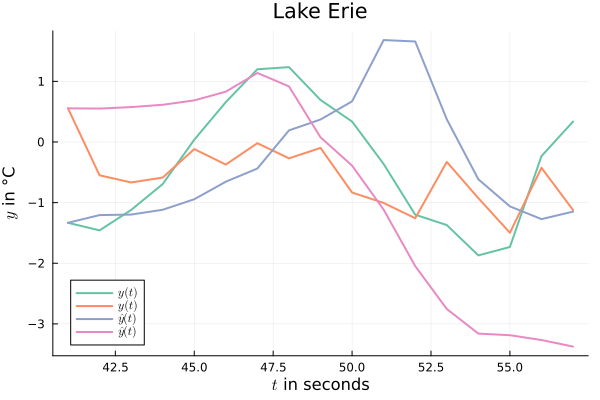

Iteration:  1100, training loss: 5.872578e+01
Iteration:  1200, training loss: 5.610192e+01
Iteration:  1300, training loss: 5.385732e+01
Iteration:  1400, training loss: 5.183393e+01
Iteration:  1500, training loss: 4.994313e+01
Given prediction error: 1.543225692219246


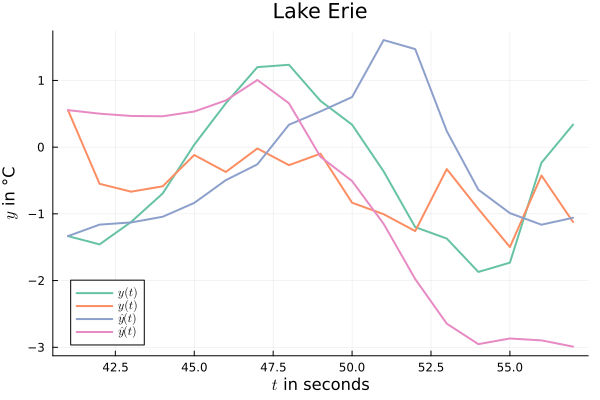

Iteration:  1600, training loss: 4.813042e+01
Iteration:  1700, training loss: 4.636317e+01
Iteration:  1800, training loss: 4.463462e+01
Iteration:  1900, training loss: 4.296052e+01
Iteration:  2000, training loss: 4.135817e+01
Given prediction error: 1.0795633857429823


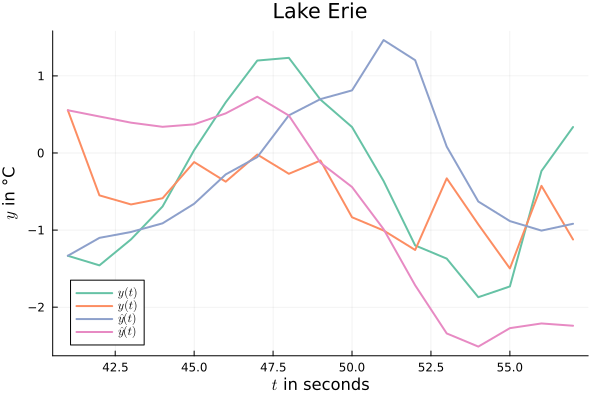

Iteration:  2100, training loss: 3.983432e+01
Iteration:  2200, training loss: 3.838788e+01
Iteration:  2300, training loss: 3.701449e+01
Iteration:  2400, training loss: 3.570865e+01
Iteration:  2500, training loss: 3.446464e+01
Given prediction error: 0.6769267174547163


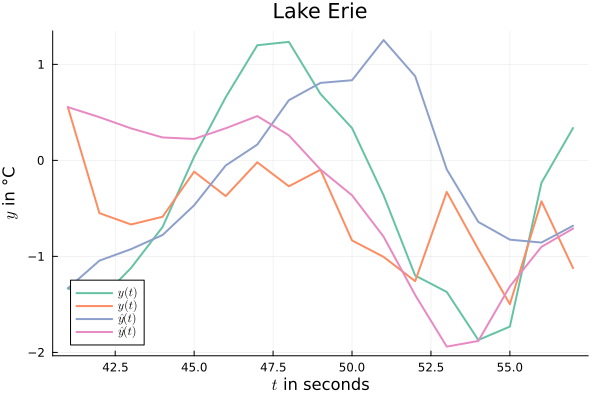

Iteration:  2600, training loss: 3.327690e+01
Iteration:  2700, training loss: 3.213984e+01
Iteration:  2800, training loss: 3.104809e+01
Iteration:  2900, training loss: 2.999708e+01
Iteration:  3000, training loss: 2.898396e+01
Given prediction error: 0.5253367114229528


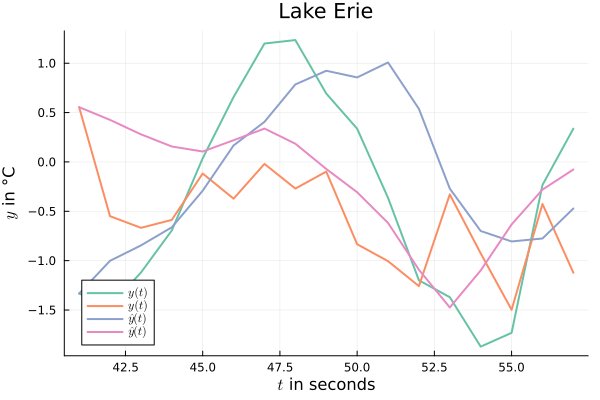

Iteration:  3100, training loss: 2.800774e+01
Iteration:  3200, training loss: 2.706828e+01
Iteration:  3300, training loss: 2.616743e+01
Iteration:  3400, training loss: 2.531086e+01
Iteration:  3500, training loss: 2.450354e+01
Given prediction error: 0.4411242438296686


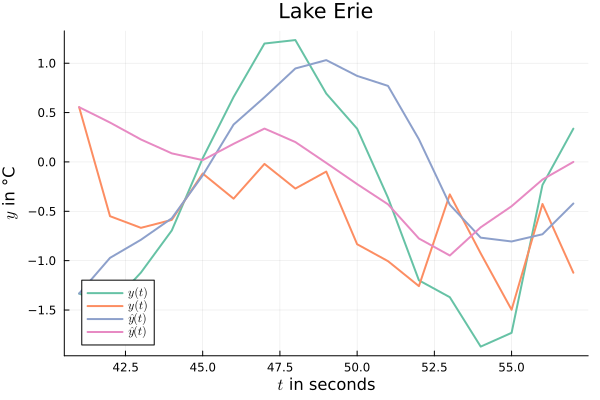

Iteration:  3600, training loss: 2.374617e+01
Iteration:  3700, training loss: 2.303697e+01
Iteration:  3800, training loss: 2.237338e+01
Iteration:  3900, training loss: 2.175243e+01
Iteration:  4000, training loss: 2.117074e+01
Given prediction error: 0.4028785419912114


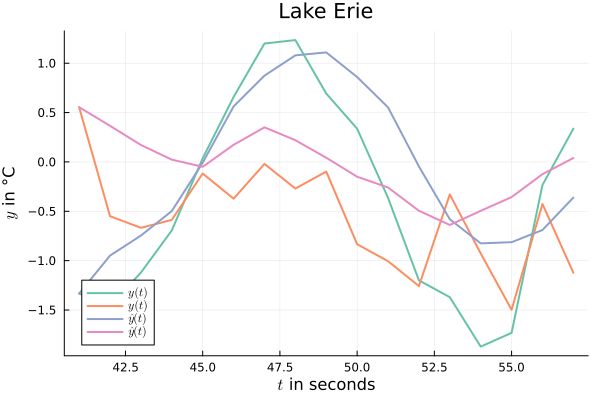

Iteration:  4100, training loss: 2.062508e+01
Iteration:  4200, training loss: 2.011264e+01
Iteration:  4300, training loss: 1.963133e+01
Iteration:  4400, training loss: 1.917954e+01
Iteration:  4500, training loss: 1.875589e+01
Given prediction error: 0.38863195293866604


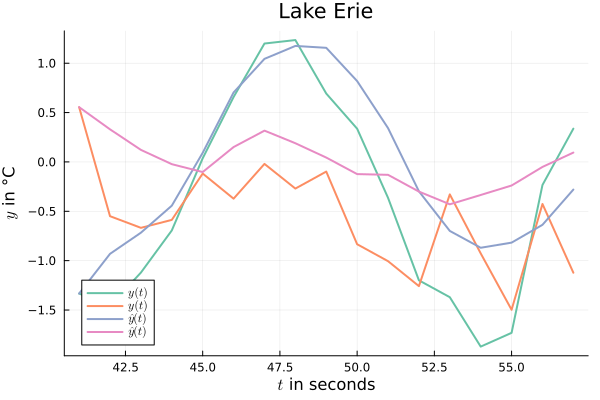

Iteration:  4600, training loss: 1.835895e+01
Iteration:  4700, training loss: 1.798705e+01
Iteration:  4800, training loss: 1.763825e+01
Iteration:  4900, training loss: 1.731022e+01
Iteration:  5000, training loss: 1.700038e+01
Given prediction error: 0.38312046746669914


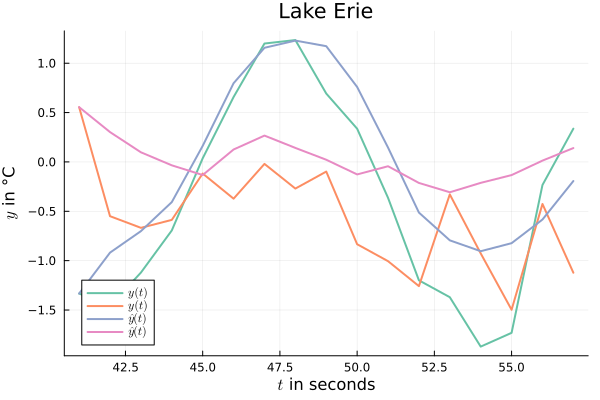

Iteration:  5000, training loss: 1.700038e+01
Given prediction error: 0.38312046746669914


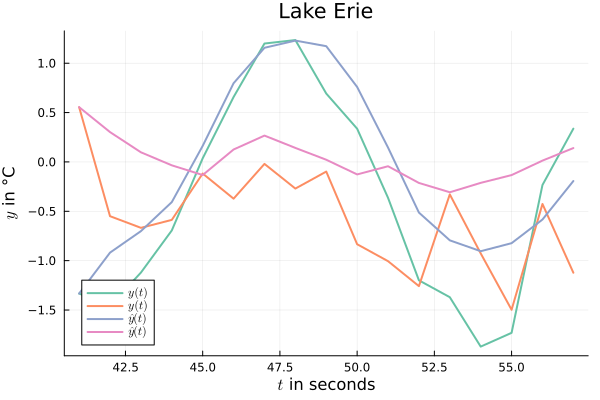

In [41]:
result_2 = nothing

### BEGIN SOLUTION

seed = 0

layer_sizes = [7, 16, 2]
hidden_layer_activation_function = tanh
output_activation = x -> x
ann = create_ann(layer_sizes, hidden_layer_activation_function, output_activation)

x0 = y_training[1, :]
w_erie, st = Lux.setup(MersenneTwister(seed), ann);
w_erie = ComponentArray(w_erie);
dxdt(x, w, t) = ann([x; interpolate_input(t)], w, st)[1]
training_problem = ODEProblem(dxdt, x0, (tsteps_training[1], tsteps_training[end]), w_erie)


function loss_NODE(w)
    pred = predict_NODE(w, training_problem, x0, tsteps_training, dt)

    loss = sum(abs2, y_training .- pred')  
    return loss
end;

adtype = Optimization.AutoZygote()
optf = Optimization.OptimizationFunction((x, p) -> loss_NODE(x), adtype)
optprob = Optimization.OptimizationProblem(optf, w_erie);

function evaluate_result(w, y_eval, tsteps_eval)

    x0 = y_eval[1, :]
    evaluation_prob = ODEProblem(dxdt, x0, (tsteps_eval[1], tsteps_eval[end]), w)

    prediction_eval = transpose(predict_NODE(w, evaluation_prob, x0, tsteps_eval, dt))

    prediction_error_eval = MSELoss()(prediction_eval, y_eval)
    println("Given prediction error: ", prediction_error_eval)
    return prediction_eval, prediction_error_eval
end

function callback(state, l)
    state.iter % 100 == 0 && @printf "Iteration: %5d, training loss: %.6e\n" state.iter l

    if state.iter % 500 == 0

        prediction_eval, prediction_error_eval = evaluate_result(state.u, y_eval, tsteps_eval)
        eval_plot = Plots.plot(tsteps_eval, y_eval, label=L"$y(t)$", title="Lake Erie", xlabel=L"$t$ in seconds", ylabel=L"$y$ in °C", legend=:bottomleft, lw=2, palette = :Set2_5)
        Plots.plot!(eval_plot, tsteps_eval, prediction_eval, label=L"$\hat{y}(t)$", lw =2)
        display(eval_plot)
    end
    
    return false
end

result_erie = Optimization.solve(optprob, OptimizationFlux.Adam(3e-3); maxiters=5_000, callback=callback)

### END SOLUTION


if @isdefined result_erie
    serialize("model_task_2", result_erie)
end

After you have trained your model, save the parameters using the code above into the file `model_task_2`. 

**Then comment out your optimization code in the cell above and remove your saving code so that both do not run in the autograding!**

**Ensure that everything that is necessary for the evaluation is still defined (Model definition etc.), i.e. that the evaluation can still run at submission!**

#### **c)** - (3 points)

Evaluate the performance of your model on the evaluation dataset. To do so, define the evaluation problem.

To gain the points for this subtask, you have to produce a model that reaches an MSE between the prediction and the eval trajectory lower than the threshold given below. Design a model architecture and optimization routine in the previous subtasks that reaches this level of accuracy.

In [42]:
result_erie = deserialize("model_task_2")
student_w = result_erie.u  # extract parameters

ComponentVector{Float32}(layer_1 = (weight = Float32[0.5759801 -0.79080343 … -0.44087565 -0.115566604; 0.90699244 -0.21401085 … 0.6531423 0.4916554; … ; 0.057740014 0.93845433 … 0.5646692 -0.6118873; 0.8702271 -0.6241481 … 0.09619004 -0.6029879], bias = Float32[-0.3344345, 0.3844142, 0.099630095, -0.008772184, 0.14837328, 0.0970158, 0.010182234, -0.039091267, -0.18666963, -0.3142802, -0.015681423, -0.21364929, 0.18976246, -0.013010563, -0.06026575, 0.077029444]), layer_2 = (weight = Float32[-0.07693846 0.0023168086 … 0.4205114 -0.014301217; -0.24735935 -0.23587929 … -0.27526826 0.0691233], bias = Float32[-0.0938471, -0.1590681]))

In [43]:
x0_eval = nothing
evaluation_prob = nothing

### BEGIN SOLUTION
x0_eval = y_eval[1, :]
dxdt(x, w, t) = ann(vcat([x; interpolate_input(t)]), w, st)[1]

evaluation_prob = ODEProblem(dxdt, x0_eval, (tsteps_eval[1], tsteps_eval[end]), student_w)
### END SOLUTION

ODEProblem with uType Vector{Float64} and tType Float32. In-place: false
timespan: (41.0f0, 57.0f0)
u0: 2-element Vector{Float64}:
 -1.3331990242004395
  0.5546457171440125

In [44]:
#public test
@assert isa(x0_eval, Array)
@assert isa(evaluation_prob, ODEProblem)

prediction_eval = transpose(predict_NODE(student_w, evaluation_prob, x0_eval, tsteps_eval, dt))


@assert length(prediction_eval) == length(y_eval)

prediction_error_eval = Flux.mse(prediction_eval, y_eval)
println("Given prediction error: ", prediction_error_eval)

@assert prediction_error_eval <= 0.5

Given prediction error: 0.3831204674666992


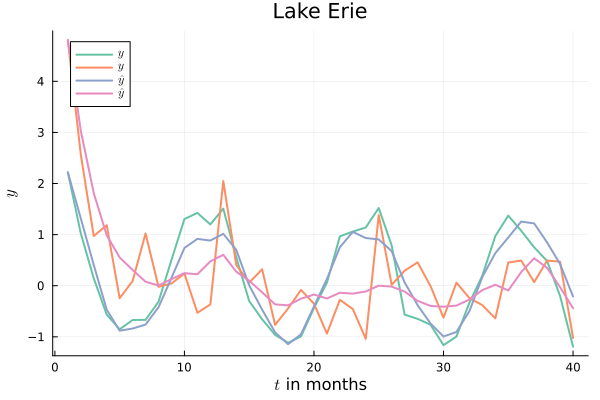

In [45]:
prediction_training = transpose(predict_NODE(student_w, training_problem, y_training[1, :] , tsteps_training, dt))

p = plot(tsteps_training, y_training, label=L"y", title="Lake Erie", xlabel=L"$t$ in months", ylabel=L"y", legend=:topleft,lw=2, palette = :Set2_5)
# plot!(p, tsteps_training, u_training, label=L"u", lw =2)
plot!(p, tsteps_training, prediction_training, label=L"\hat{y}", lw =2)

Given prediction error: 0.38312046746669914


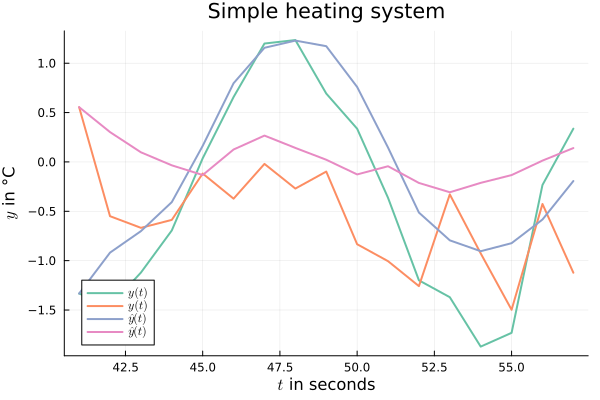

In [46]:
prediction_eval, prediction_error_eval = evaluate_result(student_w, y_eval, tsteps_eval)
eval_plot = Plots.plot(tsteps_eval, y_eval, label=L"$y(t)$", title="Simple heating system", xlabel=L"$t$ in seconds", ylabel=L"$y$ in °C", legend=:bottomleft,lw=2, palette = :Set2_5)
Plots.plot!(eval_plot, tsteps_eval, prediction_eval, label=L"$\hat{y}(t)$", lw =2)
display(eval_plot)